# 14 Capstone: End-to-End Autonomous Landing Workflow

This notebook composes earlier concepts. It is a compact workflow, not the source of all introductory explanations.


## Imports

Imports are kept separate so the instructional cells can focus on TAL semantics.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from IPython.display import display

import tal
from tal.viz import AOVizOptions
from tal.core import BatchConcatOptions
from tal.frames import FrameGraph, get_or_create_frame
from tal.spatial import Position, Rotation, Pose, PathSolveOptions
from tal.utils.frame_ops import frame_retag

from pathlib import Path
import sys

_release_dir = Path.cwd()
if not (_release_dir / '_helpers.py').exists():
    candidate = Path.cwd() / 'examples' / 'release'
    if candidate.exists():
        _release_dir = candidate
if str(_release_dir) not in sys.path:
    sys.path.append(str(_release_dir))

from _helpers import (
    build_framegraph_spatial_payloads,
    build_topology_edge_payloads,
    compact_dataset,
    display_result,
    explain_expected_failure,
    make_imu_gps_alignment_aos,
    make_kinematics_demo_objects,
    make_pose_demo_objects,
    show_ao,
    summarize_ao,
)


## Workflow map

Generate synthetic logs -> construct AOs -> synchronize timebases -> apply spatial/frame semantics -> compute distance -> extract events -> group and visualize.


In [2]:
# 1. Generate Raw Data
n_trials = 30
trials = [f"trial_{i}" for i in range(n_trials)]
outcomes = ['intercept'] * (n_trials // 2) + ['miss'] * (n_trials - (n_trials // 2))

rng = np.random.default_rng(7)
max_drone_samples = 101  # nominal 10 Hz
max_ship_samples = 11    # nominal 1 Hz

# Different-length trials (left-packed). TAL uses group_size to ignore padding.
drone_sizes = rng.integers(72, max_drone_samples + 1, size=n_trials, dtype=np.int64)
ship_sizes = rng.integers(7, max_ship_samples + 1, size=n_trials, dtype=np.int64)

ship_pos_arr = np.full((n_trials, max_ship_samples, 3), np.nan, dtype=float)
ship_time_arr = np.full((n_trials, max_ship_samples), np.nan, dtype=float)

drone_pos_arr = np.full((n_trials, max_drone_samples, 3), np.nan, dtype=float)
drone_time_arr = np.full((n_trials, max_drone_samples), np.nan, dtype=float)

for i in range(n_trials):
    t_ship_i = np.linspace(0.0, 10.0, int(ship_sizes[i]), dtype=float)
    ship_time_arr[i, : ship_sizes[i]] = t_ship_i
    ship_pos_arr[i, : ship_sizes[i], 0] = 2.0 * t_ship_i
    ship_pos_arr[i, : ship_sizes[i], 1] = 0.0
    ship_pos_arr[i, : ship_sizes[i], 2] = 0.0

    t_drone_i = np.linspace(0.0, 10.0, int(drone_sizes[i]), dtype=float)
    drone_time_arr[i, : drone_sizes[i]] = t_drone_i
    drone_pos_arr[i, : drone_sizes[i], 0] = 2.5 * t_drone_i  # X: slightly overtakes ship
    drone_pos_arr[i, : drone_sizes[i], 2] = np.clip(50.0 - 5.5 * t_drone_i, 0, None)  # Z: descends to deck
    if outcomes[i] == 'intercept':
        drone_pos_arr[i, : drone_sizes[i], 1] = 50.0 - 5.0 * t_drone_i + rng.normal(0.0, 0.2, int(drone_sizes[i]))
    else:
        drift = float(rng.uniform(2.0, 4.0))
        drone_pos_arr[i, : drone_sizes[i], 1] = 50.0 - 4.5 * t_drone_i + drift + rng.normal(0.0, 0.2, int(drone_sizes[i]))

# 2. Wrap in xarray Datasets with Metadata
ship_ds = xr.Dataset(
    {'position': (('trial', 'sample', 'axis'), ship_pos_arr)},
    coords={
        'trial': trials,
        'sample': np.arange(max_ship_samples),
        'axis': ['x', 'y', 'z'],
        'time': (('trial', 'sample'), ship_time_arr),
        'group_size': ('trial', ship_sizes),
        'outcome': ('trial', outcomes),
    },
)

drone_ds = xr.Dataset(
    {'position': (('trial', 'sample', 'axis'), drone_pos_arr)},
    coords={
        'trial': trials,
        'sample': np.arange(max_drone_samples),
        'axis': ['x', 'y', 'z'],
        'time': (('trial', 'sample'), drone_time_arr),
        'group_size': ('trial', drone_sizes),
        'outcome': ('trial', outcomes),
    },
)

# 3. Ingest into TAL AnalysisObjects
ship_ao = tal.AnalysisObject.from_data(
    ship_ds,
    sequence_dim='sample',
    batch_dims=['trial'],
    core_dims=['axis'],
    param_coord='time',
    sequence_size_coord='group_size',
)

drone_ao = tal.AnalysisObject.from_data(
    drone_ds,
    sequence_dim='sample',
    batch_dims=['trial'],
    core_dims=['axis'],
    param_coord='time',
    sequence_size_coord='group_size',
)

display_result(
    'Input AO summary',
    pd.DataFrame(
        [
            {'object': 'drone_ao', 'dims': dict(drone_ao.as_dataset().sizes), 'valid_samples_min': int(drone_sizes.min()), 'valid_samples_max': int(drone_sizes.max())},
            {'object': 'ship_ao', 'dims': dict(ship_ao.as_dataset().sizes), 'valid_samples_min': int(ship_sizes.min()), 'valid_samples_max': int(ship_sizes.max())},
        ]
    ),
)


#### Input AO summary

,object,dims,valid_samples_min,valid_samples_max
0,drone_ao,"{'trial': 30, 'sample': 101, 'axis': 3}",72,101
1,ship_ao,"{'trial': 30, 'sample': 11, 'axis': 3}",7,11


,object,dims,valid_samples_min,valid_samples_max
0,drone_ao,"{'trial': 30, 'sample': 101, 'axis': 3}",72,101
1,ship_ao,"{'trial': 30, 'sample': 11, 'axis': 3}",7,11


A spatial checkpoint at the start makes the rest of the workflow easier to interpret: ship and drone positions are trajectories in the same world axes.

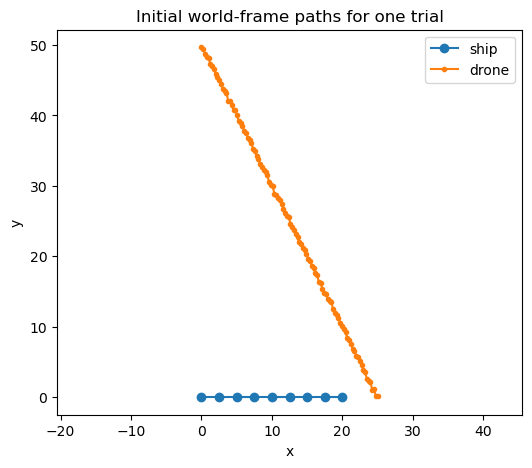

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
trial = 'trial_0'
ship_path = ship_ao.as_dataset()['position'].sel(trial=trial)
drone_path = drone_ao.as_dataset()['position'].sel(trial=trial)
ax.plot(ship_path.sel(axis='x'), ship_path.sel(axis='y'), 'o-', label='ship')
ax.plot(drone_path.sel(axis='x'), drone_path.sel(axis='y'), '.-', label='drone')
ax.set(title='Initial world-frame paths for one trial', xlabel='x', ylabel='y')
ax.axis('equal')
ax.legend(loc='best')


## Generate raw data and construct AOs

The synthetic arrays are shaped like real logs: batched, ragged, and sampled at different rates.


In [4]:
# Interpolate the low-rate ship data onto the high-rate drone timeline
synced_ship_ao = ship_ao.param.interp_like(drone_ao, on='time')

print(f"Ship resampled from {ship_ao.as_dataset().sizes['sample']} to {synced_ship_ao.as_dataset().sizes['sample']} samples.")

# Upgrade to strict Spatial Types and tag their reference frames
ship_pos = Position(synced_ship_ao)
drone_pos = Position(drone_ao)

ship_pos = frame_retag(ship_pos, parent='world', child='ship')
drone_pos = frame_retag(drone_pos, parent='world', child='drone')


Ship resampled from 11 to 101 samples.


After synchronization, both streams share the drone timeline. The path shape should stay the same while the sample density changes.

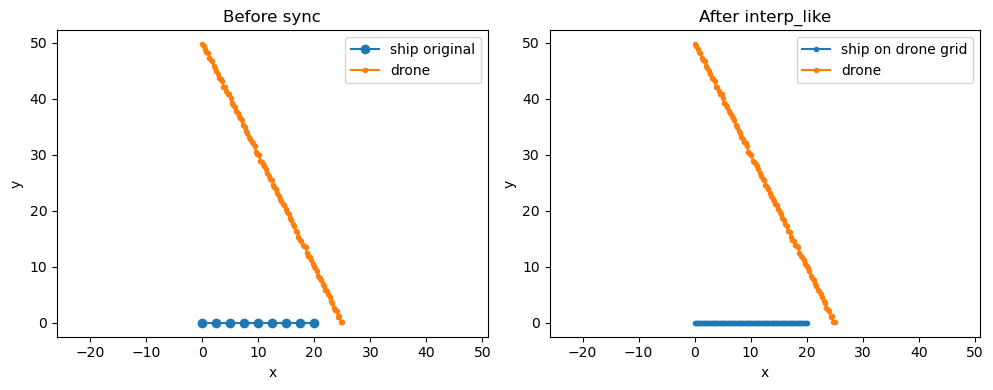

In [5]:
ship_view = ship_ao.as_dataset(copy='shallow')
drone_view = drone_ao.as_dataset(copy='shallow')
synced_ship_view = synced_ship_ao.as_dataset(copy='shallow')
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
trial = 'trial_0'
axes[0].plot(ship_view['position'].sel(trial=trial, axis='x'), ship_view['position'].sel(trial=trial, axis='y'), 'o-', label='ship original')
axes[0].plot(drone_view['position'].sel(trial=trial, axis='x'), drone_view['position'].sel(trial=trial, axis='y'), '.-', label='drone')
axes[0].set(title='Before sync', xlabel='x', ylabel='y')
axes[0].axis('equal')
axes[0].legend(loc='best')

axes[1].plot(synced_ship_view['position'].sel(trial=trial, axis='x'), synced_ship_view['position'].sel(trial=trial, axis='y'), '.-', label='ship on drone grid')
axes[1].plot(drone_view['position'].sel(trial=trial, axis='x'), drone_view['position'].sel(trial=trial, axis='y'), '.-', label='drone')
axes[1].set(title='After interp_like', xlabel='x', ylabel='y')
axes[1].axis('equal')
axes[1].legend(loc='best')
fig.tight_layout()


## Synchronize timebases

Distance cannot be compared until ship and drone positions share a time grid.


In [6]:
# 1. Safely construct a STATIC Identity Rotation (No sequence_dim needed!)
identity_rot_ds = xr.Dataset(
    {'rotation': ('quat', [0.0, 0.0, 0.0, 1.0])},
    coords={'quat': ['x', 'y', 'z', 'w']}
)
identity_rot = Rotation(
    tal.AnalysisObject.from_data(identity_rot_ds, sequence_dim=None, core_dims=['quat'], validate=True)
)

# 2. Build the FrameGraph
with FrameGraph() as graph:
    world = get_or_create_frame('world')
    ship = get_or_create_frame('ship', parent=world)
    drone = get_or_create_frame('drone', parent=world)
    
    path_opts = PathSolveOptions(graph=graph)
    
    # Edge resolver automatically pairs the dynamic position with the static identity rotation
    def edge_pose_resolver(child, parent):
        if child.id == 'ship': return Pose.from_components(identity_rot, ship_pos)
        if child.id == 'drone': return Pose.from_components(identity_rot, drone_pos)
        raise ValueError("Unknown edge")

    # 3. Transform Drone into Ship's reference frame automatically!
    # TAL applies Semantic Broadcasting to combine the static identity rotation with the dynamic 100-sample trajectory.
    drone_in_ship_frame = drone_pos.to_frame(
        'ship', 
        edge_pose_fn=edge_pose_resolver, 
        opts=path_opts
    )


Expressing the drone trajectory relative to the ship turns the interception problem into a local relative-motion picture.

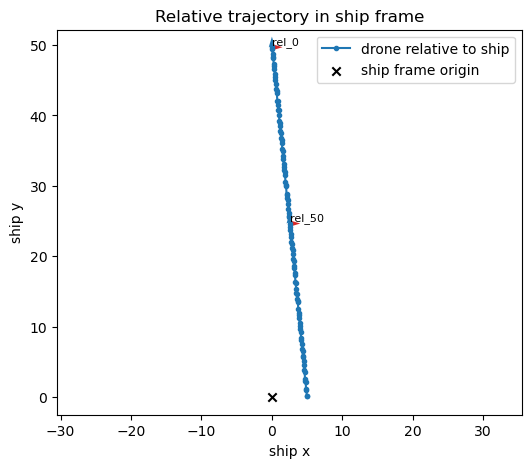

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
trial = 'trial_0'
rel = drone_in_ship_frame.as_dataset()['position'].sel(trial=trial)
x = rel.sel(axis='x').to_numpy()
y = rel.sel(axis='y').to_numpy()
ax.plot(x, y, '.-', label='drone relative to ship')

axis_length = 1.5
for idx in [0, len(x) // 2, len(x) - 1]:
    ax.quiver(x[idx], y[idx], 1.0, 0.0, angles='xy', scale_units='xy', scale=1 / axis_length, color='tab:red')
    ax.quiver(x[idx], y[idx], 0.0, 1.0, angles='xy', scale_units='xy', scale=1 / axis_length, color='tab:blue')
    ax.text(x[idx], y[idx], f'rel_{idx}', fontsize=8, ha='left', va='bottom')

ax.scatter([0.0], [0.0], marker='x', color='black', label='ship frame origin')
ax.set(title='Relative trajectory in ship frame', xlabel='ship x', ylabel='ship y')
ax.axis('equal')
ax.legend(loc='best')


## Spatial frame simplification

This demo uses identity rotations to keep the transform focused on relative position. A real system could provide dynamic orientation edge payloads.


In [8]:
# Calculate scalar distance using TAL's dimension-aware Linalg module
distance_to_ship = drone_in_ship_frame.norm()

# -- GLOBAL STATISTICS --
# What was the average minimum distance achieved across the 'intercept' vs 'miss' groups?
min_dist_per_trial = distance_to_ship.min(dim='sample')
avg_min_distance = min_dist_per_trial.group.groupby('outcome').mean(dim='trial')
display_result('Average minimum distance by outcome', avg_min_distance, data=True)

# -- EVENT EXTRACTION --
# Condition: Distance drops below 15 meters
approach_condition = distance_to_ship < 15.0

# Extract the 2 seconds before and 1 second after the perimeter breach.
# layout='segments' preserves individual trials but extracts the specific event domain.
approach_window = distance_to_ship.events.around(
    approach_condition,
    edge='enter', pre=2.0, post=1.0, dt=0.1, layout='segments'
)

# -- ENSEMBLE STATISTICS --
# Calculate the average approach trajectory for 'intercept' vs 'miss'.
# TAL safely masks out padding and tracks validity automatically.
mean_approach = approach_window.group.groupby('outcome', preserve_batch=True).mean(dim='trial')

display_result('Windowed mean distance by outcome', mean_approach, data=False)


#### Average minimum distance by outcome

,field,value
0,type,Dataset
1,dims,{'outcome': 2}
2,data_vars,[datavar]
3,coords,[outcome]
4,batch_dims,"(trial,)"
5,sequence_dim,None
6,core_dims,()
7,param_coord,None
8,sequence_size_coord,None
9,frames,None


<xarray.Dataset> Size: 32B
Dimensions:  (outcome: 2)
Coordinates:
  * outcome  (outcome) object 16B 'intercept' 'miss'
Data variables:
    datavar  (outcome) float64 16B 4.969 9.369
Attributes:
    tal:      {'version': 1, 'core': {'roles': {'batch_dims': ['trial'], 'cor...

#### Windowed mean distance by outcome

,field,value
0,type,AnalysisObject
1,dims,"{'event': 1, 'group_key': 2, 'tau': 31}"
2,data_vars,[datavar]
3,coords,"[event, group_key, tau]"
4,batch_dims,"(event, group_key)"
5,sequence_dim,tau
6,core_dims,()
7,param_coord,None
8,sequence_size_coord,None
9,frames,None


,kind,name,dims,shape,dtype
0,data_var,datavar,"(event, group_key, tau)","(1, 2, 31)",float64
1,coord,event,"(event,)","(1,)",int64
2,coord,group_key,"(group_key,)","(2,)",object
3,coord,tau,"(tau,)","(31,)",int64


## Default line explorer

The first visualization of a scalar trajectory should use the AO semantics directly: the param coordinate on x, the scalar value on y, and the batch dimension as overlays.

In [9]:
distance_line_plot = distance_to_ship.viz.line(
    opts=AOVizOptions(
        var='datavar',
        x='time',
        by=('trial',),
        max_overlay_items=n_trials,
    )
)
display(distance_line_plot)

:NdOverlay   [trial]
   :Curve   [time]   (datavar)

## Events, linalg, and statistics

A vector norm produces distance, event windows isolate terminal approach, and grouping summarizes outcomes.


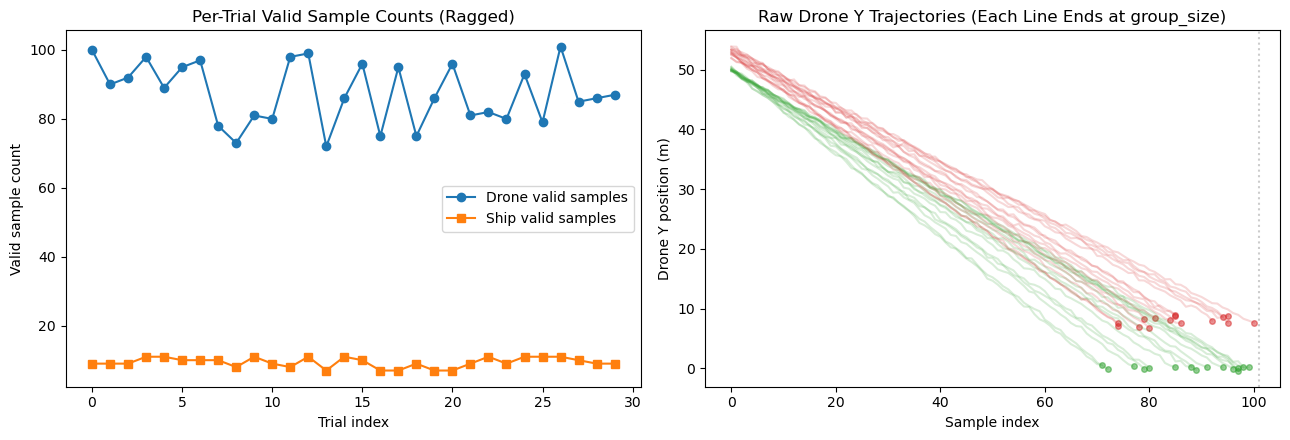

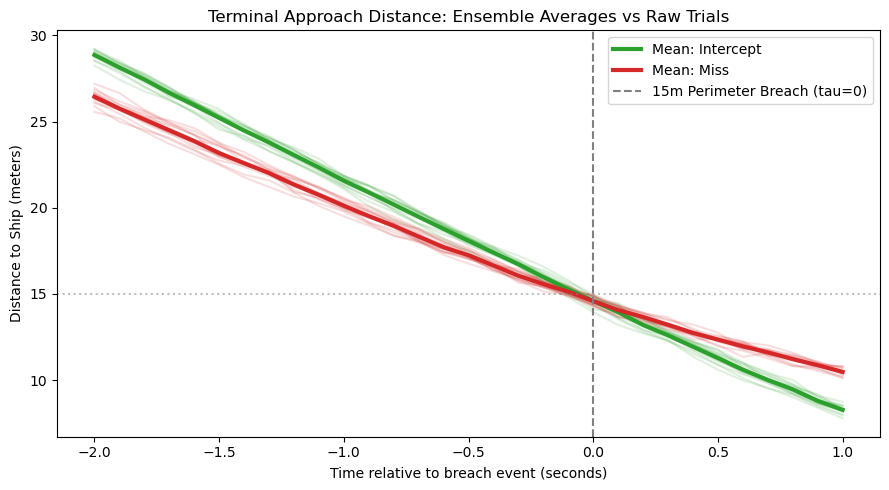

In [10]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print('Plot skipped: matplotlib is not installed.')

if plt is not None:
    drone_view = drone_ao.as_dataset(copy='shallow')
    ship_view = ship_ao.as_dataset(copy='shallow')
    approach_view = approach_window.as_dataset(copy='shallow')
    mean_approach_view = mean_approach.as_dataset(copy='shallow')
    drone_sizes = drone_view.coords['group_size'].values.astype(int)
    ship_sizes = ship_view.coords['group_size'].values.astype(int)
    trial_idx = np.arange(n_trials)

    if 'axis' in drone_view.coords and 'y' in drone_view.coords['axis'].values:
        drone_y = drone_view['position'].sel(axis='y')
    else:
        drone_y = drone_view['position'].isel(axis=1)

    fig, (ax_len, ax_sig) = plt.subplots(1, 2, figsize=(13, 4.5))

    ax_len.plot(trial_idx, drone_sizes, marker='o', linewidth=1.5, label='Drone valid samples')
    ax_len.plot(trial_idx, ship_sizes, marker='s', linewidth=1.5, label='Ship valid samples')
    ax_len.set_title('Per-Trial Valid Sample Counts (Ragged)')
    ax_len.set_xlabel('Trial index')
    ax_len.set_ylabel('Valid sample count')
    ax_len.legend(loc='best')

    for i in range(n_trials):
        n = int(drone_sizes[i])
        y = drone_y.isel(trial=i, sample=slice(0, n)).values
        outcome = str(drone_view.coords['outcome'].values[i])
        color = 'tab:green' if outcome == 'intercept' else 'tab:red'
        ax_sig.plot(np.arange(n), y, color=color, alpha=0.18)
        ax_sig.scatter([n - 1], [y[-1]], color=color, s=16, alpha=0.5)

    ax_sig.axvline(int(np.max(drone_sizes)), color='gray', linestyle=':', alpha=0.4)
    ax_sig.set_title('Raw Drone Y Trajectories (Each Line Ends at group_size)')
    ax_sig.set_xlabel('Sample index')
    ax_sig.set_ylabel('Drone Y position (m)')

    plt.tight_layout()
    plt.show()

    tau_name = 'window_tau' if 'window_tau' in approach_view.coords else 'tau'
    tau = approach_view.coords[tau_name].values

    # Get raw event data (dim names may include dynamic suffixes depending on previous runs, we select first event)
    event_dim = [d for d in approach_view.dims if 'event' in d][0]
    raw_data = approach_view['datavar'].isel({event_dim: 0})

    # Get mean data
    mean_data = mean_approach_view['datavar'].isel({event_dim: 0})
    group_dim = 'outcome' if 'outcome' in mean_data.dims else 'group_key'

    fig, ax = plt.subplots(figsize=(9, 5))

    trial_count = int(raw_data.sizes.get('trial', 0))
    for i in range(trial_count):
        outcome = str(raw_data.coords['outcome'].values[i])
        color = 'tab:green' if outcome == 'intercept' else 'tab:red'
        ax.plot(tau, raw_data.isel(trial=i).values, color=color, alpha=0.15)

    ax.plot(tau, mean_data.sel({group_dim: 'intercept'}).values, label='Mean: Intercept', color='tab:green', linewidth=3)
    ax.plot(tau, mean_data.sel({group_dim: 'miss'}).values, label='Mean: Miss', color='tab:red', linewidth=3)

    ax.axvline(0.0, color='gray', linestyle='--', label='15m Perimeter Breach (tau=0)')
    ax.axhline(15.0, color='gray', linestyle=':', alpha=0.5)

    ax.set_title('Terminal Approach Distance: Ensemble Averages vs Raw Trials')
    ax.set_xlabel('Time relative to breach event (seconds)')
    ax.set_ylabel('Distance to Ship (meters)')
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()


## Visualization and labeled outputs

The plots answer two checks: are trials ragged, and how do event-centered distance profiles differ by outcome?


## Conclusion

This capstone composed construction, param alignment, spatial typing, frame topology, linalg, events, grouping, and plotting.

**Extensions:** change the breach threshold, add camera/ship configuration as another batch coordinate, or persist the final metrics with `to_zarr`.
